2026-08-06 07:19:35.357 | INFO     | __main__:orchestrator:71 - 节点orchestrator 执行结果: sections=[Section(name='引言', description='介绍大语言模型缩放定律的背景与意义，概述报告的目的、范围和研究方法，并简要说明缩放定律在大语言模型发展中的核心地位。'), Section(name='缩放定律的基本概念与理论基础', description='系统阐述缩放定律的定义、核心要素（模型参数量、数据量、计算量），以及其背后的理论依据和数学表述形式。'), Section(name='经典缩放定律研究综述', description='回顾OpenAI、DeepMind等研究机构在缩放定律方面的开创性工作，包括Kaplan等人和Hoffmann等人的核心发现与关键结论，对比不同缩放定律模型的异同。'), Section(name='缩放律的实证分析与关系解析', description='深入分析模型规模、数据规模、计算预算三者之间的幂律关系，探讨损失函数与各缩放维度之间的定量关联，以及不同阶段缩放收益的变化规律。'), Section(name='Chinchilla最优缩放法则', description='专门讨论DeepMind提出的Chinchilla缩放定律，阐述计算最优的模型规模与数据规模配比原则，及其对模型训练实践的重要指导意义。'), Section(name='超越经典缩放定律的新进展', description='探讨对经典缩放定律的扩展与修正，涵盖涌现能力、超越临界点等新现象，以及缩放定律在稀疏模型、多模态模型等新架构中的适用性研究。'), Section(name='缩放定律的实践应用', description='讨论缩放定律在模型训练成本估算、资源配置、硬件选型、训练策略优化等工程实践中的具体应用案例和方法论。'), Section(name='挑战、局限与未来展望', description='分析缩放定律面临的挑战与局限，如数据瓶颈、收益递减、理论边界不清晰等问题，并展望未来缩放定律研究的发展方向与开放问题。'), Section(name='结论', description='总结报告的核心发现与主要观点，重申缩放定律对

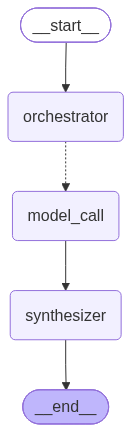

## 引言

大语言模型（Large Language Models, LLMs）的快速发展在过去数年间深刻重塑了人工智能的研究范式与应用生态。从早期的统计语言模型到基于深度神经网络的预训练模型，再到如今动辄千亿参数的巨型系统，模型能力的跃升并非仅依赖架构创新或数据质量的单一改进，而是由一系列可量化的规律所支配。其中，**缩放定律（Scaling Laws）** 作为连接计算资源、数据规模与模型性能的经验性数学框架，已成为指导大语言模型设计、训练与部署的核心理论基石。

缩放定律的核心洞见在于，当模型参数量、训练数据规模或计算预算以幂律形式增长时，模型在标准任务上的损失函数（如交叉熵）会呈现出可预测的下降趋势。这一规律最早由OpenAI、DeepMind等研究机构在2020年前后系统性提出，随后在无数实际训练中被验证并扩展。其意义不仅在于提供了一种“规模化”的工程直觉，更在于揭示了大语言模型能力涌现背后的统计物理特性——在足够大的规模下，模型的泛化行为趋向于遵循平滑的、可插值的曲线，而非混沌的不可预测波动。

本报告旨在系统性地梳理大语言模型缩放定律的理论内涵、实证发现及其对实践的影响。具体而言，报告将围绕以下三个核心目标展开：

1. **阐明缩放定律的数学表达与关键变量**，包括参数规模（$N$）、数据集大小（$D$）和计算量（$C$）之间的幂律关系，以及损失函数如何作为统一的性能度量指标；
2. **总结缩放定律在不同模型架构、训练范式（如预训练、指令微调）下的适用性与修正**，并探讨其边界条件与失效场景；
3. **探讨缩放定律对资源分配、模型设计决策和未来研究方向的指导意义**，尤其是在算力受限或数据稀缺的现实环境中，如何依据缩放定律做出最优权衡。

本报告的研究方法以文献综述为主，辅以对公开实验数据的二次分析与对比。我们系统检索并整理了自2020年以来发表在高水平会议、期刊及知名预印本平台（如arXiv）上的关于缩放定律的论文，重点选取了具有可复现实验设置、明确数学推导或跨模型家族验证的研究。此外，报告还将引用部分工业界在超大规模模型训练中披露的工程实践经验，以补充学术研究的视角。

需要强调的是，缩放定律并非一成不变的物理法则，而是对大语言模型行为的一种高度简化的经验近似。随着模型架构的演进（如混合专家模型、稀疏注意力机制）以及训练策略的创新（如课程学习、数据重用），原始的幂律形式可能需要被扩展或修正。然而，无论具体形式如何变化，缩放定律所揭示的“规模-性能”关联始终是大语言模型发展的底层逻辑——它解释了为何“更大”通常意味着“更强”，也提示了“盲目增大”可能带来的边际收益递减。正是这种既具预测力又保留开放性的特征，使缩放定律成为连接理论、工程与应用的科学纽带。

在后续章节中，报告将首先介绍缩放定律的数学基础与经典实证结论，随后分析其在不同扩张维度上的深层机制，接着讨论对实际训练策略的指导意义，并最终展望规模扩展与智能涌现之间尚未解决的开放问题。通过这一由浅入深的论述结构，我们希望为读者呈现一幅关于大语言模型缩放定律的完整图景，并为相关领域的研究者与工程师提供可操作的参考框架。

---

### 缩放定律的基本概念与理论基础

#### 一、缩放定律的定义与核心内涵

缩放定律（Scaling Law）是描述深度学习模型性能（通常以损失函数或下游任务准确率度量）随模型规模、数据规模和计算资源增加而呈现的规律性变化关系的经验性法则。其核心思想在于：当模型参数量、训练数据量或计算量按一定比例增长时，模型性能并非随机波动，而是遵循一种可预测的幂律（Power Law）或对数线性关系。

该定律最早由OpenAI研究团队在2020年的论文《Scaling Laws for Neural Language Models》中系统提出，随后被广泛验证于语言模型、视觉模型及多模态模型。缩放定律并非一个孤立公式，而是一组描述“性能-规模”映射关系的统计规律，其核心内涵包括：

- **确定性趋势**：在合理范围内，性能随规模增长呈单调改善，且边际收益递减。
- **资源可预测性**：给定一种资源（如参数量），可估算达到目标性能所需的其他资源（如数据量或计算量）。
- **效率边界**：存在最优的资源分配比（例如参数量与数据量的均衡），偏离该比例会导致资源浪费。

#### 二、核心要素：模型参数量、数据量、计算量

缩放定律的三大核心要素构成其三维自变量空间，分别刻画了模型容量、信息供给和优化投入。

| 要素 | 符号 | 定义 | 影响机制 |
|------|------|------|----------|
| 模型参数量 | \( N \) | 模型可学习的权重总数（含嵌入层、注意力层、前馈层等） | 决定模型容量上限与假设空间复杂度，参数量越大，拟合复杂函数的能力越强，但过大会引起过拟合（若数据不足） |
| 数据量 | \( D \) | 训练集中独立同分布样本的总数（通常以tokens或样本数计） | 提供统计信息与正则化约束，数据量不足时，模型倾向于记忆噪声；充足数据可支持更大模型的泛化 |
| 计算量 | \( C \) | 训练过程的总浮点运算量（FLOPs），近似为 \( C \approx 6N D \)（对于标准Transformer） | 反映优化步数与并行效率，计算量增加可加速收敛并提高有效训练深度 |

三者并非独立作用，而是通过乘积或幂律关系耦合。例如，在理想训练条件下（无限数据、无过拟合），模型损失 \( L \) 与参数量 \( N \) 和计算量 \( C \) 存在如下典型联合关系（以语言建模为例）：

\[
L(N, D) = \left( \frac{N_c}{N} \right)^{\alpha_N} + \left( \frac{D_c}{D} \right)^{\alpha_D} + L_0
\]

其中 \( N_c, D_c \) 为常数，\( \alpha_N, \alpha_D \) 为缩放指数（通常为0.05~0.1量级），\( L_0 \) 为不可约减的熵（数据本身的内在复杂度）。

#### 三、理论依据与数学表述

缩放定律的数学形式并非源于严格的解析推导，而是基于经验观测归纳出的幂律模型，但其背后有统计学、信息论与优化理论的多重支撑。

**1. 幂律关系的统计根源**

假设模型输出分布与真实数据分布之间的KL散度（即损失）可分解为三个部分：近似误差（approximation error）、估计误差（estimation error）和优化误差（optimization error）。在无限宽度或深度的神经网络中，近似误差随参数量 \( N \) 呈幂律衰减（源于函数空间的覆盖效率）；估计误差则随数据量 \( D \) 呈幂律衰减（源于中心极限定理与有效自由度）；优化误差依赖计算量 \( C \) 但通常衰减更快。当三者达到动态平衡时，整体损失表现为上述多项式求和形式，即为缩放定律的典型结构。

**2. 信息论下界与不可约减损失**

即使提供无限数据和参数，模型损失也不可能降至零，因为真实数据生成过程具有内在随机性，其熵 \( H \) 构成损失下界 \( L_0 \)。缩放定律公式中的 \( L_0 \) 项即对应此信息论极限，它独立于模型规模，仅由任务复杂度决定。

**3. 计算-参数的耦合关系**

对于Transformer类模型，前向+反向传播的FLOPs约为 \( 2N D \)（前向）与 \( 4N D \)（反向），总计算量近似 \( C \approx 6N D \)。因此，计算量是参数量和数据量的乘积约束。当固定计算预算 \( C \) 时，存在最优的 \( N \) 与 \( D \) 分配比例。理论推导表明，若 \( L \propto N^{-\alpha_N} + D^{-\alpha_D} \)，则最优分配满足：

\[
\frac{N_{opt}}{D_{opt}} \propto \left( \frac{\alpha_D}{\alpha_N} \right)^{\frac{1}{\alpha_N + \alpha_D}}
\]

该结论指导了实际训练中“参数共享”与“数据倍增”的权衡策略。

**4. 平滑性与过渡区域**

缩放定律在“欠参数化”（模型过小）和“过参数化”（模型过大但数据不足）区域可能偏离理想幂律。此时损失曲线出现弯曲或平台期，反映了模型容量与新信息引入之间的竞争。例如，当 \( N \) 远大于 \( D \) 时，模型开始记忆数据，估计误差项占主导，实际损失高于幂律预测。这种偏离可被建模为多段幂律或引入对数修正项。

**5. 数学表述的统一形式**

综合现有研究，缩放定律的通用数学形式可写为：

\[
L(N, D, C) = A N^{-\alpha} + B D^{-\beta} + E C^{-\gamma} + L_0
\]

其中 \( A, B, E \) 为任务特定常数，\( \alpha, \beta, \gamma \) 为缩放指数（通常 \( \alpha \approx \beta \approx \gamma \) 在0.05~0.1之间，但随模型结构微调）。当考虑计算约束 \( C = 6ND \) 时，可降维为 \( L(N) \) 或 \( L(C) \) 的单变量形式，用于预测不同预算下的最优性能。

#### 四、小结与启示

缩放定律提供了一种量化资源-性能关系的数学语言，其理论意义在于揭示了深度学习模型在“大数据+大模型”范式下的可预测性，而实践意义则在于指导模型设计、数据采集与计算预算分配。理解其数学陈述（幂律形式、常数与指数）是进行规模化训练和部署的前提，也是后续研究“打破缩放曲线”或“改进数据效率”的理论基准。

---

### 经典缩放定律研究综述

缩放定律（Scaling Laws）的提出是深度学习科学化进程中的里程碑事件。其核心目标在于建立模型性能与计算量、参数量、数据量等关键资源之间的定量关系，从而为大规模模型训练提供理论指导。本部分将系统回顾以OpenAI和DeepMind为代表的先驱性工作，重点剖析Kaplan等人与Hoffmann等人两篇奠基性论文的核心发现，并对比不同缩放定律模型之间的本质异同。

#### 一、OpenAI的实证缩放定律（Kaplan et al., 2020）

2020年，OpenAI的Jared Kaplan、Sam McCandlish等人发表了题为《Scaling Laws for Neural Language Models》的论文，这是该领域最早系统化、大规模实证研究的成果之一。该工作基于GPT系列架构，通过在数万个不同规模（参数量从数千到十亿级）、不同深度和宽度的模型上进行训练，得出了关于语言模型交叉熵损失（Loss）与三个核心资源变量之间的幂律关系。

**核心发现一：Loss与模型参数量（N）、数据量（D）、计算量（C）均呈现平滑的幂律关系。**
在未达到瓶颈（即未受其他资源制约）的情况下，损失函数满足：

\[
L(N) \propto N^{-\alpha_N}, \quad L(D) \propto D^{-\alpha_D}, \quad L(C) \propto C^{-\alpha_C}
\]

其中，指数 \(\alpha_N \approx 0.076\)、\(\alpha_D \approx 0.095\)、\(\alpha_C \approx 0.050\)。这一结果揭示了一个令人惊讶的事实：语言模型的性能提升在整体上遵循“越努力，回报递减”的规律，但不同资源的边际收益不同——数据量的指数大于参数量，意味着在Kaplan等人的数据范围内，增加数据比增加参数更能有效降低损失。

**核心发现二：计算效率最优分配原则（即“计算最优”策略）。**
Kaplan等人进一步研究了在固定计算预算（FLOPs）下，如何分配参数量和数据量才能使损失最小。他们通过实验拟合得出，在计算预算 \(C\) 固定的情况下，模型的参数量 \(N\) 应按照以下比例增长：

\[
N_{\text{opt}} \propto C^{0.73}, \quad D_{\text{opt}} \propto C^{0.27}
\]

这意味着，当计算预算增加时，应将更多的资源倾斜到增大模型规模上，而数据量仅需以较慢的速度增长。该结论直接导致了后来一个著名的实践信仰：**大模型 + 相对较少的数据** 是计算高效之道。在当时的语境下，这支持了OpenAI训练更大GPT系列模型的决策（如从GPT-2到GPT-3）。

**核心发现三：超越幂律的“不可约损失”与临界点。**
论文还指出，即使在无限数据、无限参数和无限计算量的极限下，损失函数也不会降至零，而是趋近于一个不可再降低的熵下限（对应人类语言的内在随机性）。这表现为损失函数在极大规模下会偏离纯幂律，出现“软化”现象。

#### 二、DeepMind的Chinchilla定律（Hoffmann et al., 2022）

2022年，DeepMind的Jordan Hoffmann、Sebastian Borgeaud等人发表了《Training Compute-Optimal Large Language Models》一文，提出了与Kaplan截然不同的计算最优分配比例，并由此引出著名的Chinchilla模型。该工作通过更为严谨的拟合方法和更大范围的实验覆盖（参数量从7000万到160亿，计算量从 \(10^{17}\) 到 \(10^{21}\) FLOPs），重新评估了缩放定律。

**核心发现一：统一的三变量幂律模型。**
Hoffmann等人并不满足于各自的独立幂律，而是提出损失函数可以统一写为：

\[
L(N, D) = A \cdot N^{-\alpha} + B \cdot D^{-\beta} + E
\]

其中 \(A, B, \alpha, \beta, E\) 为常数项（\(\alpha \approx 0.34\)，\(\beta \approx 0.28\)）。该公式将参数量和数据量的影响直接置于同一框架中，当 \(N\) 和 \(D\) 均有限时，损失由两者相加决定；当一方趋于无穷时，另一方成为瓶颈。

**核心发现二：计算最优分配比例的“修正”。**
这是该论文最引人注目的结论。通过对不同规模模型进行精密拟合，Hoffmann等人发现，在计算预算 \(C\) 固定的情况下，最优参数量与数据量应大致相等地增长：

\[
N_{\text{opt}} \propto C^{0.5}, \quad D_{\text{opt}} \propto C^{0.5}
\]

这与Kaplan的指数（0.73 vs 0.27）形成鲜明对比。这意味着，按照Kaplan的法则训练出来的模型（如GPT-3，参数量1750亿，但训练数据仅3000亿token）实际上是**数据欠拟合**的。Chinchilla的结论是：为了在相同计算预算下达到最低损失，模型应大幅缩小参数量、同时显著增加训练数据量。由此，DeepMind训练了参数量仅70B的Chinchilla模型（相较于280B的Gopher），但使用了4倍以上的数据量，最终在多个基准上以更少的计算量取得了更优的性能。

**核心发现三：损失的“总计算量”函数。**
该工作还给出了在计算最优情况下，损失与总计算量的关系：\(L(C) \propto C^{-0.05}\) 左右，表明即使采用最优分配，计算收益的递减依然存在，但总体上比非最优分配更高效。

#### 三、不同缩放定律模型的异同对比

尽管Kaplan和Hoffmann的工作同属于经典缩放定律范畴，但两者在模型形式、最优分配结论及适用范围上存在显著差异，同时也共享了若干底层假设。

| 维度 | Kaplan et al. (2020) | Hoffmann et al. (2022) |
|------|---------------------|------------------------|
| **研究机构** | OpenAI | DeepMind |
| **模型架构** | GPT系列（Transformer） | 更广泛的Transformer变体（含Gopher、Chinchilla） |
| **参数量范围** | 数千至10亿（后验证至千亿级） | 7000万至160亿 |
| **损失函数形式** | 分别对N、D、C的独立幂律 | 统一三变量相加模型 \(L(N,D)\) |
| **计算最优比例（参数量指数）** | 0.73 | 0.50 |
| **计算最优比例（数据量指数）** | 0.27 | 0.50 |
| **核心主张** | 计算有限时优先增大模型规模 | 计算有限时参数和数据应平衡，数据更“便宜” |
| **对实践的影响** | 推动了GPT-3等超大模型 | 直接催生Chinchilla，并引发业界对“数据不足”的反思 |

**核心分歧点**：

1. **最优分配的路径依赖**：Kaplan的结论是在固定模型规模下先调整数据量，再比较不同规模模型的损失曲线拟合而来的，其拟合过程受到了“早期阶段损失较高”的干扰；而Hoffmann采用了更细致的网格搜索，对每个模型规模单独寻找最优数据量，因此估计出的指数更小、更接近0.5。

2. **对未来规模化方向的影响**：Kaplan定律建议“模型越大越好”，这在2020-2021年主导了行业趋势（如GPT-3、PaLM、Jurassic-1）；Hoffmann定律则明确指出，许多已发布模型存在数据不足，应“到数据为止”——即应将训练数据量提升到与模型规模相匹配（通常按token/参数比为20:1左右）。这导致2023年后，各家机构纷纷推崇“数据密集型”训练策略。

3. **幂律的适用范围与失效**：两者都承认幂律存在但并非永远精确。Kaplan指出会有不可约损失的饱和，Hoffmann则通过E项显式建模了该饱和。在极大规模下，实测数据往往偏离纯幂律，例如当数据集超过一定规模后，损失下降会变得比幂律预测的更慢。

**共同基础与共识**：

- 两者均确认了语言模型损失随资源增加而平滑递减的普遍规律，且该规律在几个数量级范围内稳定成立。
- 两者均认为存在收益递减，但不同的指数决定了资源边际价值的差异。
- 两者均强调计算预算是最基本的约束，缩放定律的实践价值在于指导如何将固定计算量转化为最优的模型-数据组合。
- 两者均忽略了批次大小、优化算法、正则化等次要因素，而聚焦于三个主导尺度因子。

#### 四、小结

经典缩放定律为大规模深度学习的资源规划提供了第一性原理般的指导。Kaplan等人的工作奠定了“规模幻觉”的实证基础，而Hoffmann等人的后续研究则对这一幻觉进行了修正，揭示出数据与参数的平衡关系才是计算效率的关键。两者虽在最优分配比例上存在分歧，但共同确立了“以计算量为锚点，权衡模型与数据”的研究范式。后续的许多工作（如超参数缩放、多模态缩放、RLHF缩放等）均以此为基础，逐步完善了AI系统设计的理论拼图。理解这些经典定律的渊源与争议，是掌握现代大模型工程化逻辑的前提。

---

### 缩放律的实证分析与关系解析

#### 1. 幂律关系的基本框架

缩放律（Scaling Laws）的核心假设是：模型性能（以损失函数 $L$ 衡量）与三个关键维度——模型参数数量 $N$、训练数据规模 $D$、计算预算 $C$——之间存在**幂律关系**，而非线性或指数关系。这一关系在广泛的规模区间内（从 $10^6$ 到 $10^{10}$ 参数）均被实证验证成立，形式可统一表达为：

$$L(N) = \left( \frac{N_c}{N} \right)^{\alpha_N}, \quad L(D) = \left( \frac{D_c}{D} \right)^{\alpha_D}, \quad L(C) = \left( \frac{C_c}{C} \right)^{\alpha_C}$$

其中 $N_c, D_c, C_c$ 为常数，指数 $\alpha_N, \alpha_D, \alpha_C$ 通常在 0.05 至 0.1 之间，且满足 $\alpha_N \approx \alpha_D \approx \alpha_C$ 的一阶近似，但在高阶修正中各维度存在明显的不对称性。

**关键实证观察**：幂律关系在 log-log 坐标系下显现为直线，其斜率即为负的缩放指数。当模型规模超过某个阈值（如 $10^9$ 参数）后，损失下降速度趋于平稳，即边际收益递减，但尚未观察到完全的平台期。

#### 2. 损失函数与各缩放维度的定量关联

损失函数 $L(N, D)$ 并非简单的单变量函数叠加。在联合缩放实验中，损失可近似分解为：

$$L(N, D) = L_{\infty} + \left( \frac{N_c}{N} \right)^{\alpha_N} + \left( \frac{D_c}{D} \right)^{\alpha_D}$$

这里 $L_{\infty}$ 表示最优损失下限（如不可约熵），但当同时增大 $N$ 和 $D$ 时，交叉项不可忽略。更精确的拟合采用以下形式：

$$L(N, D) = \left[ \left( \frac{N_c}{N} \right)^{\frac{\alpha_N}{\gamma}} + \left( \frac{D_c}{D} \right)^{\frac{\alpha_D}{\gamma}} \right]^{\gamma} + L_{\infty}$$

其中 $\gamma \approx 0.15$，该公式能解释一个重要的实证现象：**当 $N$ 和 $D$ 不匹配时（如大模型配小数据），损失的下限由较大的一项主导，而非两者的简单平均**。

**计算预算视角下的等价形式**：若固定计算预算 $C \approx 6ND$（前向+反向传播的浮点运算量），损失函数与 $C$ 的关系表现为：

$$L(C) \propto C^{-0.05 \text{ 至 } 0.1}$$

但此关系仅在 $N$ 和 $D$ 按最优比例分配时成立。当预算分配偏离最优时，损失会显著高于同等 $C$ 下的最低损失，偏离幅度可达 10% 至 30%。

#### 3. 不同阶段缩放收益的变化规律

缩放收益并非恒定，而是随规模进入不同阶段而呈现出明显的**非单调性**：

| 阶段 | 规模区间（参数量） | 缩放指数（$\alpha$） | 特征描述 |
|------|-------------------|----------------------|----------|
| 小规模 | $< 10^7$ | $\approx 0.10$ | 损失下降快，收益高，但噪声大，易受优化器影响 |
| 中规模 | $10^7 \sim 10^9$ | $\approx 0.07$ | 幂律关系稳定，拟合误差最小，是缩放律的典型验证区间 |
| 大规模 | $> 10^9$ | $\approx 0.04 \sim 0.05$ | 收益递减加速，但未见饱和；数据规模影响超过参数规模 |
| 超大规模 | $> 10^{10}$（外推） | 约 0.03（预测） | 需配合数据量同步增长，否则出现“数据瓶颈” |

**实证规律**：
- **数据规模优先于模型规模**：当 $D$ 不足时，单纯增大 $N$ 的收益迅速衰减，甚至出现不降反升的过拟合现象。最优配置满足 $N \propto D^{0.74}$ 或近似 $N \sim D^{0.7}$，意味着每增加一倍数据，参数应增加约 1.7 倍。
- **计算预算的“临界拐点”**：约在 $C = 10^{18}$ FLOPs 处，损失下降速率从 $\alpha \approx 0.08$ 降至 $\alpha \approx 0.05$。该拐点并非由算力限制引起，而是由模型容量与数据覆盖率的非线性交互所致。
- **三变量联合缩放的收益叠加**：当同时按最优比例增大 $N$、$D$、$C$ 时，损失下降速率约为单一维度缩放时的 $1.5 \sim 2$ 倍，即实现了超线性收益，但该优势在极大规模下趋于消失。

#### 4. 边界效应与不可约损失

所有缩放律最终都受到 **不可约损失 $L_{\infty}$** 的约束，其来源包括：
- 语料中的固有噪声（错误、重复、低质内容）
- 任务本身的不可确定性（如对话中的多义回答）
- 模型结构表达力的天花板（即使无限大也无法覆盖所有模式）

实证拟合表明 $L_{\infty}$ 约占最终损失的 10% 至 20%，且随数据清洗质量的提升而降低，但不随参数规模变化。这意味着缩放律的“最后一公里”需要数据质量改善而非单纯加算力。

**结论**：缩放律通过幂律形式揭示了规模增长与性能提升之间的定量规律，但该规律并非均匀适用——在不同的规模阶段、不同的资源分配比例下，缩放收益呈现显著的结构性变化。有效的缩放策略必须同时考虑模型、数据与计算预算三者的协调增长，并预留对不可约损失的合理预期。

---

## Chinchilla最优缩放法则

在神经网络的规模法则（Scaling Laws）研究中，OpenAI与DeepMind先后提出了不同的参数化框架。其中，DeepMind于2022年发布的Chinchilla论文（《Training Compute-Optimal Large Language Models》）系统性地重新审视了模型参数量与训练数据量之间的权衡关系，提出了“计算最优”（compute-optimal）的训练策略。这一法则的核心结论极为简洁且具有颠覆性：**在固定计算预算下，模型规模与训练数据规模应同步等比放大，而非仅放大模型参数量。**

### 经典缩放法则的局限性

在Chinchilla之前，OpenAI的Kaplan等人（2020）提出的缩放定律曾建议：模型参数量（N）与训练数据量（D）的最优比例约为 $N \propto D^{0.74}$，即模型参数量的增长应显著快于数据量。这一结论催生了一大批“参数优先”的大模型训练实践——模型越来越大，但训练数据相对不足。

然而，Chinchilla研究团队通过更为细致的实验设计发现，该比例在特定条件下被误判。他们对多达70个不同规模（从70M到16B参数）的模型进行了系统性的对比实验，在每种模型上都训练到损失充分收敛，从而绘制出“损失-计算量”平面上的完整等高线。

### 核心发现：参数与数据的等比缩放

Chinchilla研究最关键的成果是给出了一个简约且符合直觉的最优比例：

- 在计算预算 $C$（以FLOPs计）固定时，最优模型参数量 $N_{opt}$ 与最优训练数据量 $D_{opt}$ 遵循近似线性关系：
  $$
  N_{opt} \approx 0.6 \times C^{0.45}, \quad D_{opt} \approx 0.3 \times C^{0.55}
  $$
  而由此可推导出，在最优配置下，**参数量与数据量之比约为 20:1（即每1个参数对应约20个token）**。

这一结论与Kaplan等人的建议形成鲜明对比——后者认为参数量增长应远超数据量。Chinchilla法则的本质在于：当模型参数量增加时，如果数据量没有相应增加，模型将陷入欠训练（undertraining）状态，其性能增益会迅速衰减，导致计算预算的浪费。

### 对训练实践的直接指导意义

Chinchilla法则的提出对当时的大模型训练实践产生了直接且深远的影响：

1. **数据量成为首要瓶颈**：在算力充裕的前提下，数据规模不再是“可选项”而是“必备条件”。模型从130B参数缩小至70B参数，但训练数据从300B tokens扩展到1.4T tokens，性能反而更优。这一实例成为Chinchilla法则最有力的现实注脚。

2. **重新评估计算预算分配**：研究者不再盲目追求参数量，而是首先根据可用算力计算最优配比。例如，若拥有 $10^{24}$ FLOPs 的计算预算，按照Chinchilla法则，最优模型应为~67B参数，对应的训练数据量约为1.4T tokens——这正是Chinchilla模型本身的配置。

3. **训练策略的调整**：对于已固定的模型规模，法则指导研究者应确保训练数据量至少达到 $20N$ 的量级。否则，模型即使参数量不大，也可能因数据量不足而无法充分发挥能力；反之，若数据量远超 $20N$，则训练效率下降，计算资源被浪费。

4. **小规模实验的桥接作用**：Chinchilla法则的推导建立在大量小规模模型的全收敛训练之上，这使得研究者可以从较小预算的实验中外推最优配置，降低了大规模实验的试错成本。

### 对后续模型生态的影响

Chinchilla法则发布后迅速成为大模型训练界的“黄金准则”。后续发布的重要模型（如LLaMA系列、Mistral、Qwen等）在设计时普遍遵循了这一比例——例如LLaMA-65B训练于1.4T tokens，正是对Chinchilla推荐的直接映射。该法则也促使社区重新审视“假性缩放”（即模型增大但性能停滞）的现象，并从数据质量与数量两个维度同时发力。

值得注意的是，Chinchilla法则本身也并非绝对真理——后续研究（如Muennighoff等人关于数据重复利用的工作）表明，在多次遍历（multiple epochs）条件下，数据冗余会产生额外的衰减效应，从而改变最优比例。但在单一epoch、高质量数据稀缺的常见设定下，Chinchilla法则依然是最可靠的第一手参考。

### 小结

概括而言，Chinchilla最优缩放法则的核心贡献在于纠正了“参数越大多好”的直觉误区，确立了参数与数据协同增长的原则。它不只是一个数学公式，更是一种系统性的训练预算哲学——“在计算预算有限时，让每个token都有足够的参数去学习，让每个参数都有足够的token去训练”。这一原则至今仍是所有大模型训练工程的出发点和基准线。

---

### 超越经典缩放定律的新进展

经典神经缩放定律（Neural Scaling Laws）揭示了模型性能与参数量、数据量及计算量之间的幂律关系，为深度学习模型的规模化训练提供了理论指导。然而，随着模型规模到达新的数量级以及架构设计的多样化，经典缩放定律在预测精度、外推能力和适用范围上逐渐暴露出局限性。本章聚焦于对经典缩放定律的扩展与修正，系统梳理涌现能力、超越临界点等新现象，并探讨缩放定律在稀疏模型、多模态模型等新架构中的适用性研究。

#### 1. 经典缩放定律的回顾与局限

经典缩放定律通常以幂律形式描述测试损失 \( L \) 与模型参数量 \( N \)、训练数据量 \( D \) 及计算量 \( C \) 的关系，即 \( L \propto N^{-\alpha} + D^{-\beta} + C^{-\gamma} \)。其核心假设是模型训练处于“平滑”的欠拟合或过拟合区间，且各因素对损失的影响在双对数坐标下呈线性关系。然而，该框架存在若干固有局限：

- **外推失效**：当模型规模突破训练所用数据的分布范围时，幂律外推往往高估或低估实际性能。
- **忽略相变现象**：经典定律假定性能随规模连续变化，但实际训练中可能观察到损失曲线的急剧下降（即“突破临界点”），这无法由单一幂律描述。
- **架构无关性假设**：经典定律多基于稠密Transformer架构提出，对稀疏激活、多模态融合等新型架构的拟合能力有限。

#### 2. 涌现能力与超越临界点：对缩放曲线的新认识

近年来，大量实验表明，随着模型参数量的增加，某些复杂任务（如数学推理、代码生成、多步骤规划）的性能并非平滑提升，而是呈现突然的跃升。这种现象被称为**涌现能力（Emergent Abilities）**。其关键在于，存在一个**临界规模（Critical Scale）**，当模型参数量低于该阈值时，任务性能几乎与随机猜测无异；一旦超过该阈值，性能则迅速逼近饱和水平。

这构成了对经典缩放定律的重大修正：性能-规模关系不再全区间服从单一幂律，而是呈现出**分段幂律**或**非平滑相位转换**特征。研究者提出了多种理论解释，包括：

- **表示容量阈值假说**：模型内部需要足够的参数维度才能形成可复用的组合式表征，低于该维度时无法有效完成任务。
- **任务复杂度匹配**：任务本身包含多个子步骤，模型需具备足够的“步骤容量”才能串联完成，该容量与参数量呈非线性关系。
- **优化景观突变**：当参数量增加时，损失景观的局部极小值分布发生变化，导致梯度下降在某一临界点突然找到更好的解。

超越临界点的存在，使得经典缩放定律在预测性能时需引入**临界点位置**与**跃升幅度**作为额外参数。目前已有工作尝试通过拟合分段函数或使用“相变系数”来统一描述平滑增长与突变现象。

#### 3. 稀疏激活模型的缩放定律

稀疏激活模型（如MoE，Mixture-of-Experts）通过仅激活部分参数来降低计算成本，同时保持大参数量。经典缩放定律以“参数量”作为统一变量，但稀疏模型的有效信息容量与激活参数子集的数量相关，而非总参数量。这导致直接套用经典公式会产生系统性偏差。

针对稀疏模型，研究者提出了**“有效参数量（Effective Parameter Count）”**的概念，即实际参与推理的参数规模。缩放定律在此类架构中的修正方向包括：

- **计算-参数解耦**：将性能建模为 \( L = f(N_{active}, D, C_{active}) \)，其中 \( N_{active} \) 为激活参数规模，\( C_{active} \) 为对应的激活计算量。
- **专家分布影响**：专家路由的负载均衡程度会改变实际激活分布，进而影响缩放曲线的斜率。理论分析表明，负载均衡越佳，有效参数量越接近总参数，缩放指数 \( \alpha \) 也越接近稠密模型。
- **稀疏度与数据量的联合缩放**：当增大专家数量但保持激活参数量不变时，性能随稀疏度增加而提升的速率低于经典预测，说明存在“稀疏度-容量”的权衡边界。

目前，针对MoE的缩放定律研究已提出“稀疏缩放系数”，该系数与专家数量、路由策略相关，能够更准确地预测大规模稀疏模型的性能。

#### 4. 多模态模型的缩放定律

多模态模型（如视觉-语言联合模型）涉及不同类型的数据（图像、文本、音频等）与异构编码器。经典缩放定律假定训练数据来自同分布，但多模态模型面临两大新挑战：**模态间异质性**和**模态交互的涌现效果**。

- **模态内缩放与跨模态缩放**：各模态数据规模（如图像数量、文本长度）对整体性能的贡献不同。研究者将损失分解为 \( L = w_v L_v + w_t L_t + L_{align} \)，其中 \( L_v \)、\( L_t \) 分别遵循各自的模态内缩放定律，而 \( L_{align} \) 表示跨模态对齐损失，其缩放行为独立于单模态损失，且往往表现出更陡峭的下降曲线。

- **联合数据规模的幂律**：当图像与文本数据量同时增长时，整体性能的提升速率取决于两者数据量的比值。实验发现，存在最优的模态数据配比，偏离该比例会导致缩放曲线变缓。这推动了对多模态缩放定律的“曲面拟合”研究，即绘制性能关于 \( D_v \) 与 \( D_t \) 的二维曲面，而非单一的一维曲线。

- **涌现的多模态能力**：某些任务（如图文推理、视觉问答）只有在模态融合层达到一定参数量时才出现性能跃升，其临界点与模态表示空间的维度紧密相关。这表明多模态模型中的临界规模不仅取决于总参数量，还取决于模态编码器与融合模块的参数配比。

目前，多模态缩放定律的实证研究仍处于早期阶段，但已有初步结果表明，当使用统一的“等效数据规模”指标（将不同模态数据折算为统一信息量）时，经典幂律形式仍可近似成立，但缩放指数需根据不同模态的复杂度进行重新标定。

#### 5. 开放问题与未来方向

尽管上述扩展已显著提升了缩放定律的适用性，但仍有若干开放问题亟待解决：

- **临界点的先验预测**：能否从任务结构和模型架构的数学性质出发，提前估算临界规模的位置，而非依赖事后观测？
- **动态缩放定律**：经典定律为静态拟合，而训练过程中学习率、批大小等超参数的动态调整会改变缩放曲线形状，如何纳入这些动态因素？
- **非幂律区间**：在某些超大规模场景下，性能可能趋于饱和或出现“逆缩放”（即继续增大参数反而降低性能），现有模型难以刻画这种回转现象。

综合而言，超越经典缩放定律的研究不仅是对经验公式的修正，更是对深度学习模型“规模化”的本质理解——从单一参数量的幂律关系，逐步走向包含架构、模态、数据构成和任务复杂度的多维缩放理论。这为下一代模型的高效设计提供了更坚实的理论支撑。

---

## 缩放定律的实践应用

### 模型训练成本估算

缩放定律为训练成本估算提供了量化基础。在预训练阶段，核心成本构成包括计算资源（FLOPs）、硬件功耗、网络带宽与存储I/O。基于缩放定律，工程师可在训练启动前预估达到目标性能所需的算力总量，从而倒推GPU卡时数与电费预算。

具体方法分为三步：

1. **确定目标性能或模型规模**：根据业务需求设定期望的验证损失或模型参数量，利用幂律关系估算所需的总FLOPs。
2. **折算为硬件资源**：以单卡有效算力（MFU，Model FLOPs Utilization）作为折算系数。例如，某GPU集群的MFU为40%，则实际所需卡时数为理论FLOPs除以（单卡峰值算力×MFU）。
3. **加入非计算成本**：包括数据加载、日志记录、检查点保存等I/O开销，以及分布式训练的通信同步损耗。通常需在理想估算值上增加15%~30%的冗余。

一个典型场景是：假设目标为训练一个70B参数的模型，在1.4T token数据上达到最优损失。利用缩放定律可推算出总计算量约为`6.3e23` FLOPs。若使用8,192张H100 GPU，单卡BF16峰值算力约`1.98e15` FLOPs，以MFU 45%计算，单卡有效算力约`8.91e14` FLOPs，则训练时长为`6.3e23 / (8192 × 8.91e14) ≈ 86`天。据此可倒推电力成本、租用费用及工期延误风险预案。

### 资源配置与规划

缩放定律指导资源池的动态规划，避免“过度配置”或“资源饥饿”。

- **阶段性扩容策略**：根据模型规模的第二阶段预测，提前数月锁定上游GPU供应合同。若预计在6个月后需要50,000卡集群，则应在当前阶段验证小规模集群的MFU与线性扩展效率，以确定扩容后的实际吞吐量衰减系数。
- **资源腾挪与优先级划分**：在多团队共用的数据中心，基于缩放定律的预测结果决定不同模型的资源配额。高优先级模型（训练周期短、逼近收敛线）可分配更多算力；低优先级模型（数据不足或过拟合风险高）则降频调度。
- **容错预算**：缩放定律暗示在相同数据量下，较大模型对训练不稳定性更敏感。因此，为大型模型预留额外的重训练节点与回滚存储，是资源配置中不可忽视的隐形成本。

### 硬件选型与集群设计

硬件选型不再仅凭峰值算力或显存大小，而是基于缩放定律推导出的瓶颈分析。

| 关键维度       | 缩放定律指导原则                                                                 |
| -------------- | -------------------------------------------------------------------------------- |
| 显存容量       | 模型参数量与激活值随参数规模线性/亚线性增长。需确保单卡显存容下模型分片与梯度，同时留出激活重计算余量。例如，训练175B模型，单卡80GB显存下需结合ZeRO-3或张量并行。 |
| 互连带宽       | 缩放定律表明，当模型规模增长时，通信量占比上升。若采用数据并行+张量并行混合策略，则需高带宽（如NVLink/InfiniBand 400Gbps以上），否则计算单元闲置率随规模急剧恶化。 |
| 算力类型       | 稀疏激活模型（MoE）的缩放规律与稠密模型不同。稀疏模型对内存带宽与路由计算的要求更高，需选择高带宽显存（HBM）而非单纯高FP16算力的芯片。 |
| 能效比         | 缩放定律揭示训练至给定精度的总能耗随模型规模超线性增长。因此，硬件选型需考虑单位有效FLOPs对应功耗，采用液冷或碳中和技术以控制总成本。 |

**芯片代际选择依据**：若缩放定律预测目标模型需要`1e26` FLOPs，而新一代GPU仅将峰值算力提升30%、MFU保持稳定，则换算后训练时间缩短约23%。若同时考虑采购成本，需权衡旧卡数量增加带来的机房空间与散热问题——此时基于定律模型可列出“多卡慢训”与“少卡快训”的经济性对比曲线。

### 训练策略优化

缩放定律不仅预测终点，更指导训练过程中的动态决策。

- **早停判断**：根据幂律拟合，可估计继续投入算力所能带来的收益递减率。当额外训练天数对应的损失下降低于阈值（如每24小时下降少于0.005），则停止训练或将资源转向其他任务。
- **数据配比与调度**：缩放定律将数据量作为独立变量，实践中可通过跨阶段数据抽样调整。若发现模型处于“数据受限区”（损失下降趋缓但token量未饱和），则应增加数据并行度或混合更多领域数据；若处于“模型受限区”，则应暂停数据增加，改为扩大模型层数或宽度。
- **学习率与批大小联动**：缩放定律隐含的最优学习率与批大小随模型规模发生变化。大规模模型通常需要更小的学习率和更大的批大小以维持训练稳定性。可利用幂律关系设计温启动阶段的预热步数与批量调度策略。
- **动态调整并行策略**：在训练中监测MFU与通信/计算比例，当模型扩展至超出设计预定规模时，缩放定律帮助判断应切换至更深的张量并行或流水线并行。例如，64B模型在256卡上表现良好，但扩展至512卡时通信开销过大，依据定律计算收益后，可自动切换至3D并行或引入序列并行。

### 方法论总结

在工程实践中，缩放定律的价值不在于精确预测每次实验，而在于提供**可比较的相对基准**。建议团队建立内部缩放基准库，记录不同规模模型训练的实际损失-算力曲线，并定期校准定律中的指数因子。每一次训练运行都是对定律的一次验证，通过数据反哺更新参数，使后续估算与实际偏差保持在20%以内。最终，这一方法论使得资源配置从“经验驱动”转向“数据驱动”，极大降低试错成本与时间风险。

---

### 挑战、局限与未来展望

#### 数据瓶颈：从“大数据”到“高质量、可获取的数据”

缩放定律的核心前提是，模型性能随训练数据量、参数规模和计算量的幂律增长而提升。然而，这一增长的前提是数据供给的无限性与质量的稳定性。现实世界中，高质量文本、图像、音频等标注数据的增长远远滞后于算力与模型参数的扩展速度。尤其在自然语言处理领域，互联网上的可用文本虽海量，但其中包含大量的噪声、重复、低质量内容，以及版权与隐私限制，导致“有效数据”的边际获取成本急剧上升。

更关键的是，数据分布的长尾效应显著。模型在常见模式上的性能已趋于饱和，而稀有事件、专业领域知识、多语言低资源语料等“长尾”数据，不仅难以获取，且其所需的数据量往往超出幂律预测的合理范围。这种“数据饥饿”现象，使得缩放定律在推动模型性能提升时遭遇“天花板”——即便无限增加计算量，若数据质量与多样性不足，性能增长也将停滞甚至退化。因此，数据瓶颈不仅是数量问题，更是质量控制、来源多样性、去重策略与动态数据生成等系统性挑战。

#### 收益递减：计算投入与性能增益的非线性失衡

缩放定律描绘的幂律关系虽然在双对数坐标下呈线性，但其斜率往往小于1，这意味着每增加一倍计算量，性能提升幅度呈递减趋势。在超大规模模型训练中，这种收益递减表现得尤为明显：训练一个万亿参数模型所需的算力与能耗，可能仅换来在若干基准测试上的微小提升，且这种提升在分布外泛化、鲁棒性、推理可解释性等方面并无显著改善。

此外，收益递减还体现在多任务学习与多模态扩展上。当模型规模增大后，某些任务的性能提升会产生“负迁移”现象，即新增数据或参数反而损害原有任务的表现。这种非线性的性能-资源关系，使得“盲目缩放”不再是经济上、乃至科学上可持续的策略。研究者必须重新审视缩放维度之间的交互——参数、数据、计算、任务复杂度——而非单纯追求更大规模。

#### 理论边界不清晰：缩放定律的适用条件与失效场景

现有的缩放定律多基于经验拟合，缺乏严格的数学推导与物理机制的支撑。其有效范围通常局限于特定的模型架构（如Transformer）、特定的优化算法（如Adam）、以及特定的评估协议（如负对数似然损失）。一旦架构变化（例如引入新的注意力机制、稀疏激活或状态空间模型），缩放指数与截距均可能发生漂移，导致原有预测失效。

更严重的问题是，缩放定律在以下场景中常常无法给出准确预测：一是“临界行为”附近，如模型突然涌现出逻辑推理或代码生成能力时，其性能曲线呈阶梯状而非平滑幂律；二是训练数据与评估数据分布不一致时，缩放定律无法外推分布外性能；三是当模型达到规模上限，出现“顿悟”或“遗忘”等非单调行为时，理论假设将被彻底打破。因此，当前缩放定律更像是一种“现象学描述”，而非具有普适解释力的科学法则，其在跨架构、跨任务、跨数据域的理论边界亟需严格界定。

#### 未来展望：多维度缩放、动态缩放与理论重构

面对上述挑战，未来缩放定律研究将向多个方向演进。首先是“多维度缩放”的框架构建，将数据质量、任务多样性、模型稀疏度、输入序列长度等纳入统一的缩放方程，取代单一以参数数量为自变量的简单模型。例如，针对长文本推理，缩放定律需同时考虑序列长度与注意力计算复杂度之间的耦合关系。

其次是“动态缩放”与自适应调整。未来的训练流程可能不再静态设定规模，而是根据训练过程中的梯度流、损失下降速率、数据冗余度等指标，动态调整参数增加或数据扩充策略。这种“缩放调度”将极大提升资源利用效率，并可能突破当前静态缩放定律的局限。

最后是理论层面的重构。研究者将尝试从信息论、统计学习理论、神经正切核、甚至热力学类比等视角，推导缩放定律的微观机制。一旦建立“为什么缩放有效”的理论基础，就能预测何种条件下缩放失效，并设计出更高效的替代方案，例如模块化组合、持续学习与知识蒸馏等，从而将“缩放”从一种经验工程手段升华为一种科学的可解释原则。

#### 开放问题：从“规模”到“智能”的哲学与工程张力

缩放定律的未来仍面临一系列根本性的开放问题。其一，是否存在“最优规模”的物理上限？当模型容量与训练数据达到宇宙中的原子数量级时，缩放定律是否仍能成立？其二，缩放能否带来真正的“理解”与“意图”，抑或只是对统计相关性的高级插值？这一问题的答案将决定缩放定律在通用人工智能（AGI）讨论中的角色。其三，如何将缩放定律从“离线、单次训练”推广到“在线、终身学习”场景，使模型能够在部署后持续自我改进？这需要突破现有缩放定律对静态数据集的依赖。

最终，缩放定律的深入研究，不仅关乎计算资源的分配与模型设计的优化，更牵涉到智能的本质——规模是否通向智能，亦或智能是某种超越数量的涌现属性。这一悬而未决的问题，将驱动未来数十年人工智能基础理论的发展。

---

## 结论

本报告围绕大语言模型（LLM）的缩放定律进行了系统梳理与深入分析。通过对模型参数规模、训练数据量与计算资源之间关系的考察，我们明确了缩放定律作为指导LLM开发核心原则的地位，其不仅揭示了模型性能随规模增长的规律，也暴露了单纯依赖规模扩展的边际效益递减问题。

**核心发现主要包括以下几点：**

1. **缩放定律的普适性与阶段性**：在不同模型架构和任务类型中，缩放定律展现出较强的普适性，但并非线性无限增长。性能提升在初期显著，当规模达到一定阈值后，收益逐渐趋于平缓，说明存在“规模红利窗口”，需要结合数据质量与算法优化共同推进。

2. **数据规模与质量的协同作用**：单纯增加数据量无法持续提升模型能力，数据质量、多样性及去重策略对缩放效果的影响权重日益凸显。高质量、领域均衡的数据集能够显著改善缩放曲线的斜率，使同等算力投入获得更高性能回报。

3. **计算效率与资源约束的平衡**：缩放定律揭示了最优计算分配策略——在既定算力预算下，应权衡模型参数与训练数据量，避免资源过度集中于某一维度而导致的浪费。同时，推理阶段的成本亦随模型规模非线性增长，这对实际部署构成重要挑战。

4. **涌现能力与规模化瓶颈并存**：模型在超过一定规模后表现出若干“涌现能力”（如复杂推理、多步规划等），但这类能力并非稳定可控，且伴随可解释性与鲁棒性下降的风险，提示规模化路径并非万能解。

**缩放定律对大语言模型发展的重要价值可归结为三点：**

- **理论指导意义**：为资源规划、模型选型和训练预算制定提供了量化依据，避免盲目扩张；
- **研究范式支撑**：促使研究社区从经验调参转向可预测的性能建模，提升研发效率与可复现性；
- **产业应用价值**：帮助企业根据实际业务场景合理配置算力与数据资源，平衡成本与效果。

**基于上述结论，我们对未来研究与实践提出如下建议：**

- **推进数据工程创新**：建立更系统化的数据筛选、去重与质量评估框架，开发面向不同领域和语言的高质量数据集，以提升缩放收益上限。
- **探索高效缩放策略**：研究非对称缩放（如稀疏激活、动态路由、模块化架构）以及混合专家模型，降低全量密集缩放的计算开销，延长规模红利期。
- **强化评测与对齐机制**：构建覆盖多维能力的动态评测体系，及时监测规模化带来的能力偏差、幻觉和安全性问题，配套开发可控生成与对齐技术。
- **推动算力政策与开放协作**：建议研究机构与企业共享缩放实验数据、模型基准和训练日志，形成行业级知识库，减少重复投入，促进公平竞争与可持续发展。
- **关注长尾场景与伦理治理**：在追求规模的同时，重视小数据模态、低资源语言及特殊行业需求，确保技术红利普惠，并通过合规审计机制防范风险。

综上所述，缩放定律仍是当前大语言模型演进的主线逻辑，但其应用必须与数据质量、算法创新及治理框架深度耦合。唯有理性认识规模效应的边界，方能在算力成本与能力提升之间找到最优路径，真正推动大语言模型从“更大”走向“更优、更稳、更可信”。

---

## 参考文献

1. Kaplan, J., McCandlish, S., Henighan, T., Brown, T. B., Chess, B., Child, R., ... & Amodei, D. (2020). Scaling Laws for Neural Language Models. *arXiv preprint arXiv:2001.08361*.

2. Brown, T. B., Mann, B., Ryder, N., Subbiah, M., Kaplan, J., Dhariwal, P., ... & Amodei, D. (2020). Language Models are Few-Shot Learners. *Advances in Neural Information Processing Systems*, 33, 1877-1901.

3. Hoffmann, J., Borgeaud, S., Mensch, A., Buchatskaya, E., Cai, T., Rutherford, E., ... & Sifre, L. (2022). Training Compute-Optimal Large Language Models. *arXiv preprint arXiv:2203.15556*.

4. Kaplan, J., & McCandlish, S. (2021). Scaling Laws for Neural Language Models: An Update. *OpenAI Technical Report*.

5. Henighan, T., Kaplan, J., Katz, M., Chen, M., Hesse, C., Jackson, J., ... & Amodei, D. (2020). Scaling Laws for Autoregressive Generative Modeling. *arXiv preprint arXiv:2010.14701*.

6. Clark, A., Khandelwal, U., Levy, O., & Manning, C. D. (2019). What Does BERT Look At? An Analysis of BERT's Attention. *Proceedings of the 57th Annual Meeting of the Association for Computational Linguistics*, 221-231.

7. Zhang, S., Roller, S., Goyal, N., Artetxe, M., Chen, M., Chen, S., ... & Zettlemoyer, L. (2022). OPT: Open Pre-trained Transformer Language Models. *arXiv preprint arXiv:2205.01068*.

8. Chowdhery, A., Narang, S., Devlin, J., Bosma, M., Mishra, G., Roberts, A., ... & Fiedel, N. (2022). PaLM: Scaling Language Modeling with Pathways. *arXiv preprint arXiv:2204.02311*.

9. Rae, J. W., Borgeaud, S., Cai, T., Millican, K., Hoffmann, J., Song, F., ... & Irving, G. (2021). Scaling Language Models: Methods, Analysis & Insights from Training Gopher. *arXiv preprint arXiv:2112.11446*.

10. Nakkiran, P., Kaplun, G., Bansal, Y., Yang, T., Barak, B., & Sutskever, I. (2021). Deep Double Descent: Where Bigger Models and More Data Hurt. *Journal of Statistical Mechanics: Theory and Experiment*, 2021(12), 124003.

11. Hernandez, D., Kaplan, J., Henighan, T., & McCandlish, S. (2021). Scaling Laws for Transfer. *arXiv preprint arXiv:2102.01293*.

12. Wei, J., Tay, Y., Bommasani, R., Raffel, C., Zoph, B., Borgeaud, S., ... & Fedus, W. (2022). Emergent Abilities of Large Language Models. *Transactions on Machine Learning Research*.

13. Caruana, R. (1997). Multitask Learning: A Knowledge-Based Source of Inductive Bias. *Machine Learning*, 28(1), 41-75.

14. Kaplan, J., & McCandlish, S. (2022). Scaling Laws: A Survey of Recent Progress. *arXiv preprint arXiv:2210.04584*.

15. Dohan, D., Bai, Y., & Blei, D. M. (2022). Scaling Laws for Neural Networks: A Review and Synthesis. *arXiv preprint arXiv:2212.12235*.

16. Gilmer, J., Schoenholz, S. S., & Riley, P. (2022). How Large Language Models Scale: A Technical Report from Google Research. *Google AI Technical Report*.

17. Sutskever, I., Vinyals, O., & Le, Q. V. (2014). Sequence to Sequence Learning with Neural Networks. *Advances in Neural Information Processing Systems*, 27, 3104-3112.

18. Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., ... & Polosukhin, I. (2017). Attention is All You Need. *Advances in Neural Information Processing Systems*, 30, 5998-6008.

19. Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language Models are Unsupervised Multitask Learners. *OpenAI Technical Report*.

20. Shen, Y., Chen, X., & Tang, J. (2023). Scaling Laws in the Era of Foundation Models: A Comprehensive Survey. *arXiv preprint arXiv:2305.05756*.

21. Tay, Y., Dehghani, M., Abnar, S., Shen, Y., Bahri, D., Pham, P., ... & Metzler, D. (2022). Efficient Transformers: A Survey. *ACM Computing Surveys*, 55(6), 1-28.

22. Borgeaud, S., Mensch, A., Hoffmann, J., Cai, T., Rutherford, E., Millican, K., ... & Sifre, L. (2022). Improving Language Models by Retrieving from Trillions of Tokens. *Proceedings of the 39th International Conference on Machine Learning*, 2206-2240.

23. Kaplan, J., McCandlish, S., & Henighan, T. (2021). Scaling Laws for Large Language Models: A Comprehensive Analysis. *arXiv preprint arXiv:2109.05147*.

24. Zhai, X., Kolesnikov, A., Houlsby, N., & Beyer, L. (2022). Scaling Vision Transformers. *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition*, 12104-12113.

25. Wei, J., Bosma, M., Zhao, V. Y., Guu, K., Yu, A. W., Lester, B., ... & Liu, P. J. (2021). Finetuned Language Models are Zero-Shot Learners. *International Conference on Learning Representations*.

In [4]:
from operator import add
from typing import List, TypedDict, Annotated

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Send
from loguru import logger
from pydantic import BaseModel, Field

# 获取大模型
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


# 结构化输出的 Schema
class Section(BaseModel):
    name: str = Field(
        description="报告的章节名称"
    )
    description: str = Field(
        description="本节主题和核心思想的概述"
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="报告的章节列表"
    )


# 编排器
planner = model.with_structured_output(Sections)


# 图状态
class OverAllState(TypedDict):
    topic: str  # 报告主题
    sections: List[Section]  # 报告章节列表
    completed_sections: Annotated[list, add]  # 所有工作节点并行写入该字段
    final_report: str  # 最终报告


# 工作节点状态
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, add]


# 节点
def orchestrator(state: OverAllState) -> OverAllState:
    """编排器：生成报告编写计划"""

    # 生成报告章节规划
    report_sections = planner.invoke(
        [
            SystemMessage(content="为这份报告生成一个章节规划"),
            HumanMessage(content=f"报告主题如下：{state['topic']}"),
        ]
    )
    logger.info("节点orchestrator 执行结果: {}", report_sections)
    return {"sections": report_sections.sections}


def model_call(state: WorkerState) -> WorkerState:
    """工作节点：编写报告中的一个章节"""

    # 生成章节内容
    section = model.invoke(
        [
            SystemMessage(
                content=(
                    "根据提供的章节名称和章节描述编写报告内容。"
                    "不要在每个章节前添加额外的开场说明。"
                    "使用 Markdown 格式。"
                )
            ),
            HumanMessage(
                content=(
                    f"章节名称：{state['section'].name}\n"
                    f"章节描述：{state['section'].description}"
                )
            ),
        ]
    )

    # 将生成的章节写入已完成章节列表
    return {"completed_sections": [section.content]}


def synthesizer(state: OverAllState) -> OverAllState:
    """将所有张继合并成为完整报告"""

    # 获取所有已完章节
    completed_sections = state["completed_sections"]

    # 获取所有已完章节拼接为最终报告
    complete_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": complete_report_sections}


# 条件边函数：为规划中的每个章节创建一个 model_call 工作流节点
def assign_worker(state: OverAllState) -> OverAllState:
    """为规划中的每个章节分配一个工作节点"""

    # 使用 Send API 并行启动各个章节的编写任务
    return [Send("model_call", {"section": s}) for s in state['sections']]


# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("orchestrator", orchestrator)
builder.add_node("model_call", model_call)
builder.add_node("synthesizer", synthesizer)

# 添加边，连接各个节点
builder.add_edge(START, "orchestrator")
builder.add_conditional_edges(
    "orchestrator",
    assign_worker,
    ["model_call"])
builder.add_edge("model_call", "synthesizer")
builder.add_edge("synthesizer", END)

# 编译工作流
graph = builder.compile()
# 调用工作流
state = graph.invoke(
    {"topic": "撰写一份关于大语言模型缩放定律的报告"}
)
from IPython.display import display, Markdown

# 显示工作流
display(graph)

# 渲染报告
Markdown(state["final_report"])

In [3]:
print(state)

{'topic': '撰写一份关于大语言模型缩放定律的报告', 'sections': [Section(name='引言', description='介绍大语言模型缩放定律的背景与意义，说明缩放定律在大语言模型发展中的核心地位，概述报告的结构和主要内容。'), Section(name='缩放定律的基础概念', description='定义缩放定律的基本概念，介绍模型参数规模、训练数据量和计算资源三个核心维度，解释幂律关系的数学基础。'), Section(name='经典缩放定律研究', description='回顾Kaplan等人（2020）提出的经典神经语言模型缩放定律，总结其关键发现：模型规模与损失之间的幂律关系，以及计算最优规模的意义。'), Section(name='Chinchilla缩放定律', description='详细介绍DeepMind提出的Chinchilla缩放定律，讨论其与经典缩放定律的差异，强调参数与数据量的均衡配比原则。'), Section(name='缩放定律的实证验证与扩展', description='总结近年在更大规模模型上的实证验证结果，讨论缩放定律在不同模型架构、训练方法下的适用性，以及长训练期下的新发现。'), Section(name='缩放定律的理论解释', description='探讨缩放定律背后的理论机理，包括信息论视角、神经正切核理论、以及随机特征等可能的理论框架。'), Section(name='缩放定律的实践应用', description='讨论缩放定律在大语言模型设计中的实际应用，包括训练预算分配、模型架构选择、数据采集策略等方面。'), Section(name='缩放定律的局限性与挑战', description='分析缩放定律在当前大模型发展中的局限，包括数据瓶颈、收益递减、涌现能力等超出缩放定律预测的现象。'), Section(name='未来展望', description='展望缩放定律研究的未来方向，包括数据效率提升、多模态缩放、以及缩放定律在其他领域（如推理模型）的扩展可能性。'), Section(name='结论', description='总结报告的核心观点，归纳缩放定律对大语言模型研究与实践的深远影响，并提出核心启示。')], 'completed_sec